# Modul 10 — Optimisasi & Riset Operasi
## Convergeni Data Consulting (CDC) — Klien: PT Komponen Jaya

Notebook ini menjalankan linear programming Modul 10: produksi optimal Rem
dan Transmisi, daerah layak, dan analisis kendala aktif vs longgar.

## Rumusan dan Solusi LP

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

c = [-120, -150]
A_ub = [[2, 4], [3, 2], [80, 100]]
b_ub = [800, 900, 32000]
bounds = [(0, None), (0, None)]

hasil = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
print(f"Produksi Rem: {hasil.x[0]:.0f}, Transmisi: {hasil.x[1]:.0f}")
print(f"Profit maksimum: Rp {-hasil.fun * 100000:,.0f}")

pemakaian = np.dot(A_ub, hasil.x)
nama_kendala = ["Jam mesin", "Jam tenaga kerja", "Anggaran bahan baku"]
for nama, pakai, tersedia in zip(nama_kendala, pemakaian, b_ub):
    print(f"{nama}: {pakai:.0f} dari {tersedia}")

Produksi Rem: 250, Transmisi: 75
Profit maksimum: Rp 4,125,000,000
Jam mesin: 800 dari 800
Jam tenaga kerja: 900 dari 900
Anggaran bahan baku: 27500 dari 32000


## Visualisasi 1: Daerah Layak dan Titik Optimal (Asset Baru, mengganti M10-01)

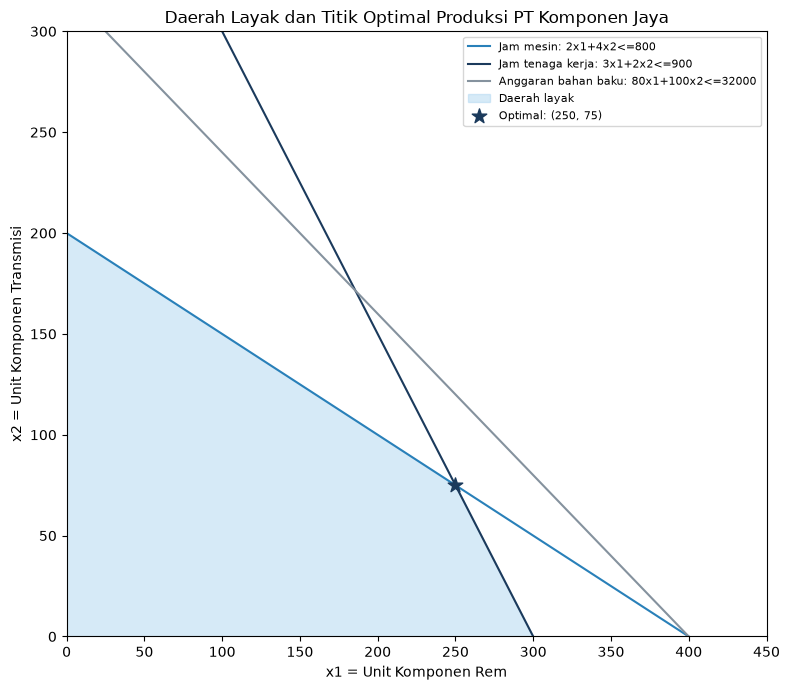

In [2]:
x1 = np.linspace(0, 450, 500)

# Batas tiap kendala dalam bentuk x2 = f(x1)
x2_mesin = (800 - 2*x1) / 4
x2_kerja = (900 - 3*x1) / 2
x2_anggaran = (32000 - 80*x1) / 100

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(x1, x2_mesin, color="#2980B9", label="Jam mesin: 2x1+4x2<=800")
ax.plot(x1, x2_kerja, color="#1B3A5C", label="Jam tenaga kerja: 3x1+2x2<=900")
ax.plot(x1, x2_anggaran, color="#85929E", label="Anggaran bahan baku: 80x1+100x2<=32000")

# Daerah layak: irisan seluruh kendala (dan x1,x2>=0)
y_layak = np.minimum(np.minimum(x2_mesin, x2_kerja), x2_anggaran)
y_layak = np.clip(y_layak, 0, None)
ax.fill_between(x1, 0, y_layak, where=(y_layak >= 0), color="#AED6F1", alpha=0.5, label="Daerah layak")

ax.scatter([hasil.x[0]], [hasil.x[1]], color="#1B3A5C", s=120, zorder=5, marker="*",
           label=f"Optimal: ({hasil.x[0]:.0f}, {hasil.x[1]:.0f})")

ax.set_xlim(0, 450)
ax.set_ylim(0, 300)
ax.set_xlabel("x1 = Unit Komponen Rem")
ax.set_ylabel("x2 = Unit Komponen Transmisi")
ax.set_title("Daerah Layak dan Titik Optimal Produksi PT Komponen Jaya")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("modul10_daerah_layak.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualisasi 2: Kendala Aktif vs Longgar (Asset Baru, mengganti M10-02)

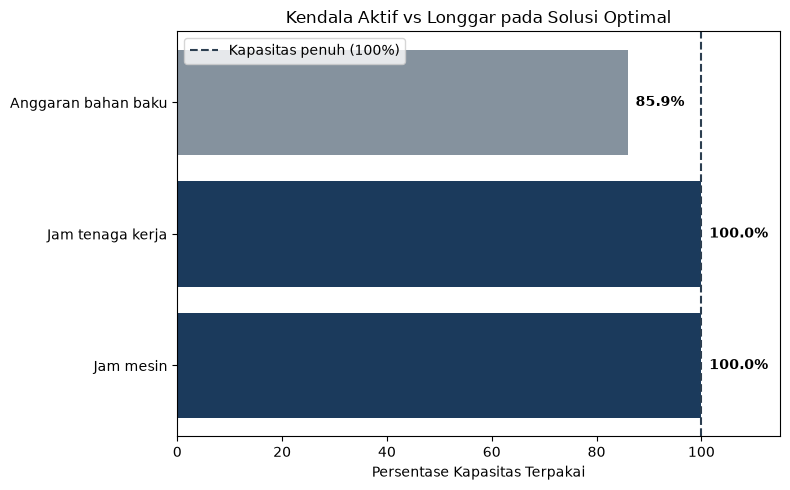

In [3]:
persen_terpakai = pemakaian / np.array(b_ub) * 100

fig, ax = plt.subplots(figsize=(8, 5))
warna = ["#1B3A5C" if p >= 99.9 else "#85929E" for p in persen_terpakai]
bars = ax.barh(nama_kendala, persen_terpakai, color=warna)
ax.axvline(100, color="#2C3E50", linestyle="--", linewidth=1.5, label="Kapasitas penuh (100%)")
ax.set_xlabel("Persentase Kapasitas Terpakai")
ax.set_title("Kendala Aktif vs Longgar pada Solusi Optimal")
ax.set_xlim(0, 115)
for i, (bar, p) in enumerate(zip(bars, persen_terpakai)):
    ax.text(p + 1.5, i, f"{p:.1f}%", va="center", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("modul10_kendala_aktif.png", dpi=150, bbox_inches="tight")
plt.show()